# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [7]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [8]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?


The main objective of this project is to develop a model that can predict the assessed property value (taxvaluedollarcnt) based on various property features. In business terms, this can help Zillow better estimate home values, support pricing decisions, and improve the accuracy of property listings. More accurate predictions can also help users make informed decisions when buying or selling homes.

**1.2:**  How will your solution be used?


The solution could be used as part of an automated valuation system that estimates property values based on available data. For example, it could assist real estate platforms in generating price estimates for listings, or help internal teams identify properties that may be under- or over-valued. It could also support marketing and analytics teams by highlighting key factors that influence property value.

**1.3:**  How should success (or failure) be measured?


Success should be measured by how accurately the model predicts property values compared to actual values. This can be evaluated using metrics such as mean squared error (MSE) or root mean squared error (RMSE). In addition, consistency and generalization to new data are important, meaning the model should perform well not only on training data but also on unseen data. Failure would be indicated by large prediction errors or unstable performance across different datasets.

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [12]:
# Look at the first few rows
df.head()

,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


In [9]:
# Check dataset shape
print(f"Dataset shape: {df.shape}")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")

Dataset shape: (77613, 55)
Number of samples: 77613
Number of features: 55


In [10]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  f

In [11]:
# Number of unique values per feature
df.nunique()

parcelid                        77414
airconditioningtypeid               5
architecturalstyletypeid            5
basementsqft                       43
bathroomcnt                        22
bedroomcnt                         16
buildingclasstypeid                 2
buildingqualitytypeid              12
calculatedbathnbr                  21
decktypeid                          1
finishedfloor1squarefeet         1787
calculatedfinishedsquarefeet     4972
finishedsquarefeet12             4868
finishedsquarefeet13               13
finishedsquarefeet15             1724
finishedsquarefeet50             1807
finishedsquarefeet6               350
fips                                3
fireplacecnt                        5
fullbathcnt                        13
garagecarcnt                       14
garagetotalsqft                   839
hashottuborspa                      1
heatingorsystemtypeid              10
latitude                        64038
longitude                       62461
lotsizesquar

In [14]:
# Percentage of missing values
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_percent.head(10)

buildingclasstypeid         99.980673
finishedsquarefeet13        99.945885
storytypeid                 99.935578
basementsqft                99.935578
yardbuildingsqft26          99.909809
fireplaceflag               99.778388
architecturalstyletypeid    99.733292
typeconstructiontypeid      99.712677
finishedsquarefeet6         99.502661
pooltypeid10                99.400874
dtype: float64

In [13]:
# Combine key feature information into one table
feature_summary = pd.DataFrame({
    'dtype': df.dtypes,
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().mean() * 100).round(2),
    'unique_values': df.nunique()
})

# Sort by missing percentage
feature_summary = feature_summary.sort_values(by='missing_pct', ascending=False)

# Display top features with most missing values
feature_summary.head(20)

,dtype,missing_count,missing_pct,unique_values
buildingclasstypeid,float64,77598,99.98,2
finishedsquarefeet13,float64,77571,99.95,13
storytypeid,float64,77563,99.94,1
basementsqft,float64,77563,99.94,43
yardbuildingsqft26,float64,77543,99.91,59
fireplaceflag,object,77441,99.78,1
architecturalstyletypeid,float64,77406,99.73,5
typeconstructiontypeid,float64,77390,99.71,4
finishedsquarefeet6,float64,77227,99.50,350
pooltypeid10,float64,77148,99.40,1


#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

Categorical features in this dataset include both variables stored as object types and some numerical features that actually represent categories. Based on the data, object-type features such as `propertycountylandusecode`, `propertyzoningdesc`, `fireplaceflag`, and `taxdelinquencyflag` are clearly categorical. In addition, several numerical features function as encoded categories, including `airconditioningtypeid`, `buildingqualitytypeid`, `heatingorsystemtypeid`, and region-based features like `regionidcity`, `regionidcounty`, and `regionidzip`. These features represent groups or classifications rather than continuous values, so they should be treated as categorical during preprocessing.

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly. 

Yes, several features appear to have little usefulness for predicting property value. The most obvious example is `parcelid`, which is a unique identifier and does not provide meaningful information for prediction. Additionally, some features such as `assessmentyear` have no variation (only one unique value), meaning they do not contribute any useful signal. There are also highly specific identifier-like features, such as `rawcensustractandblock` and `censustractandblock`, which have very high uniqueness and are unlikely to generalize well in a model.

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 

Yes, many features have extremely high percentages of missing values, making them unreliable for modeling. For example, features like `buildingclasstypeid`, `finishedsquarefeet13`, `basementsqft`, and `storytypeid` have over 99% missing values. Other features, such as `yardbuildingsqft26` and `fireplaceflag`, also have very high missing rates. With such limited available data, imputing these features would not be reliable, so they are strong candidates for removal.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example. 

Yes, some features are not useful due to having either too many or too few unique values. Features like `parcelid` have almost one unique value per row, meaning they act as identifiers and do not help the model learn patterns. On the other hand, features such as `decktypeid`, `poolcnt`, and `hashottuborspa` have only one unique value (or very little variation), meaning they provide no useful information. Both types of features are unlikely to contribute to prediction and can be removed.

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

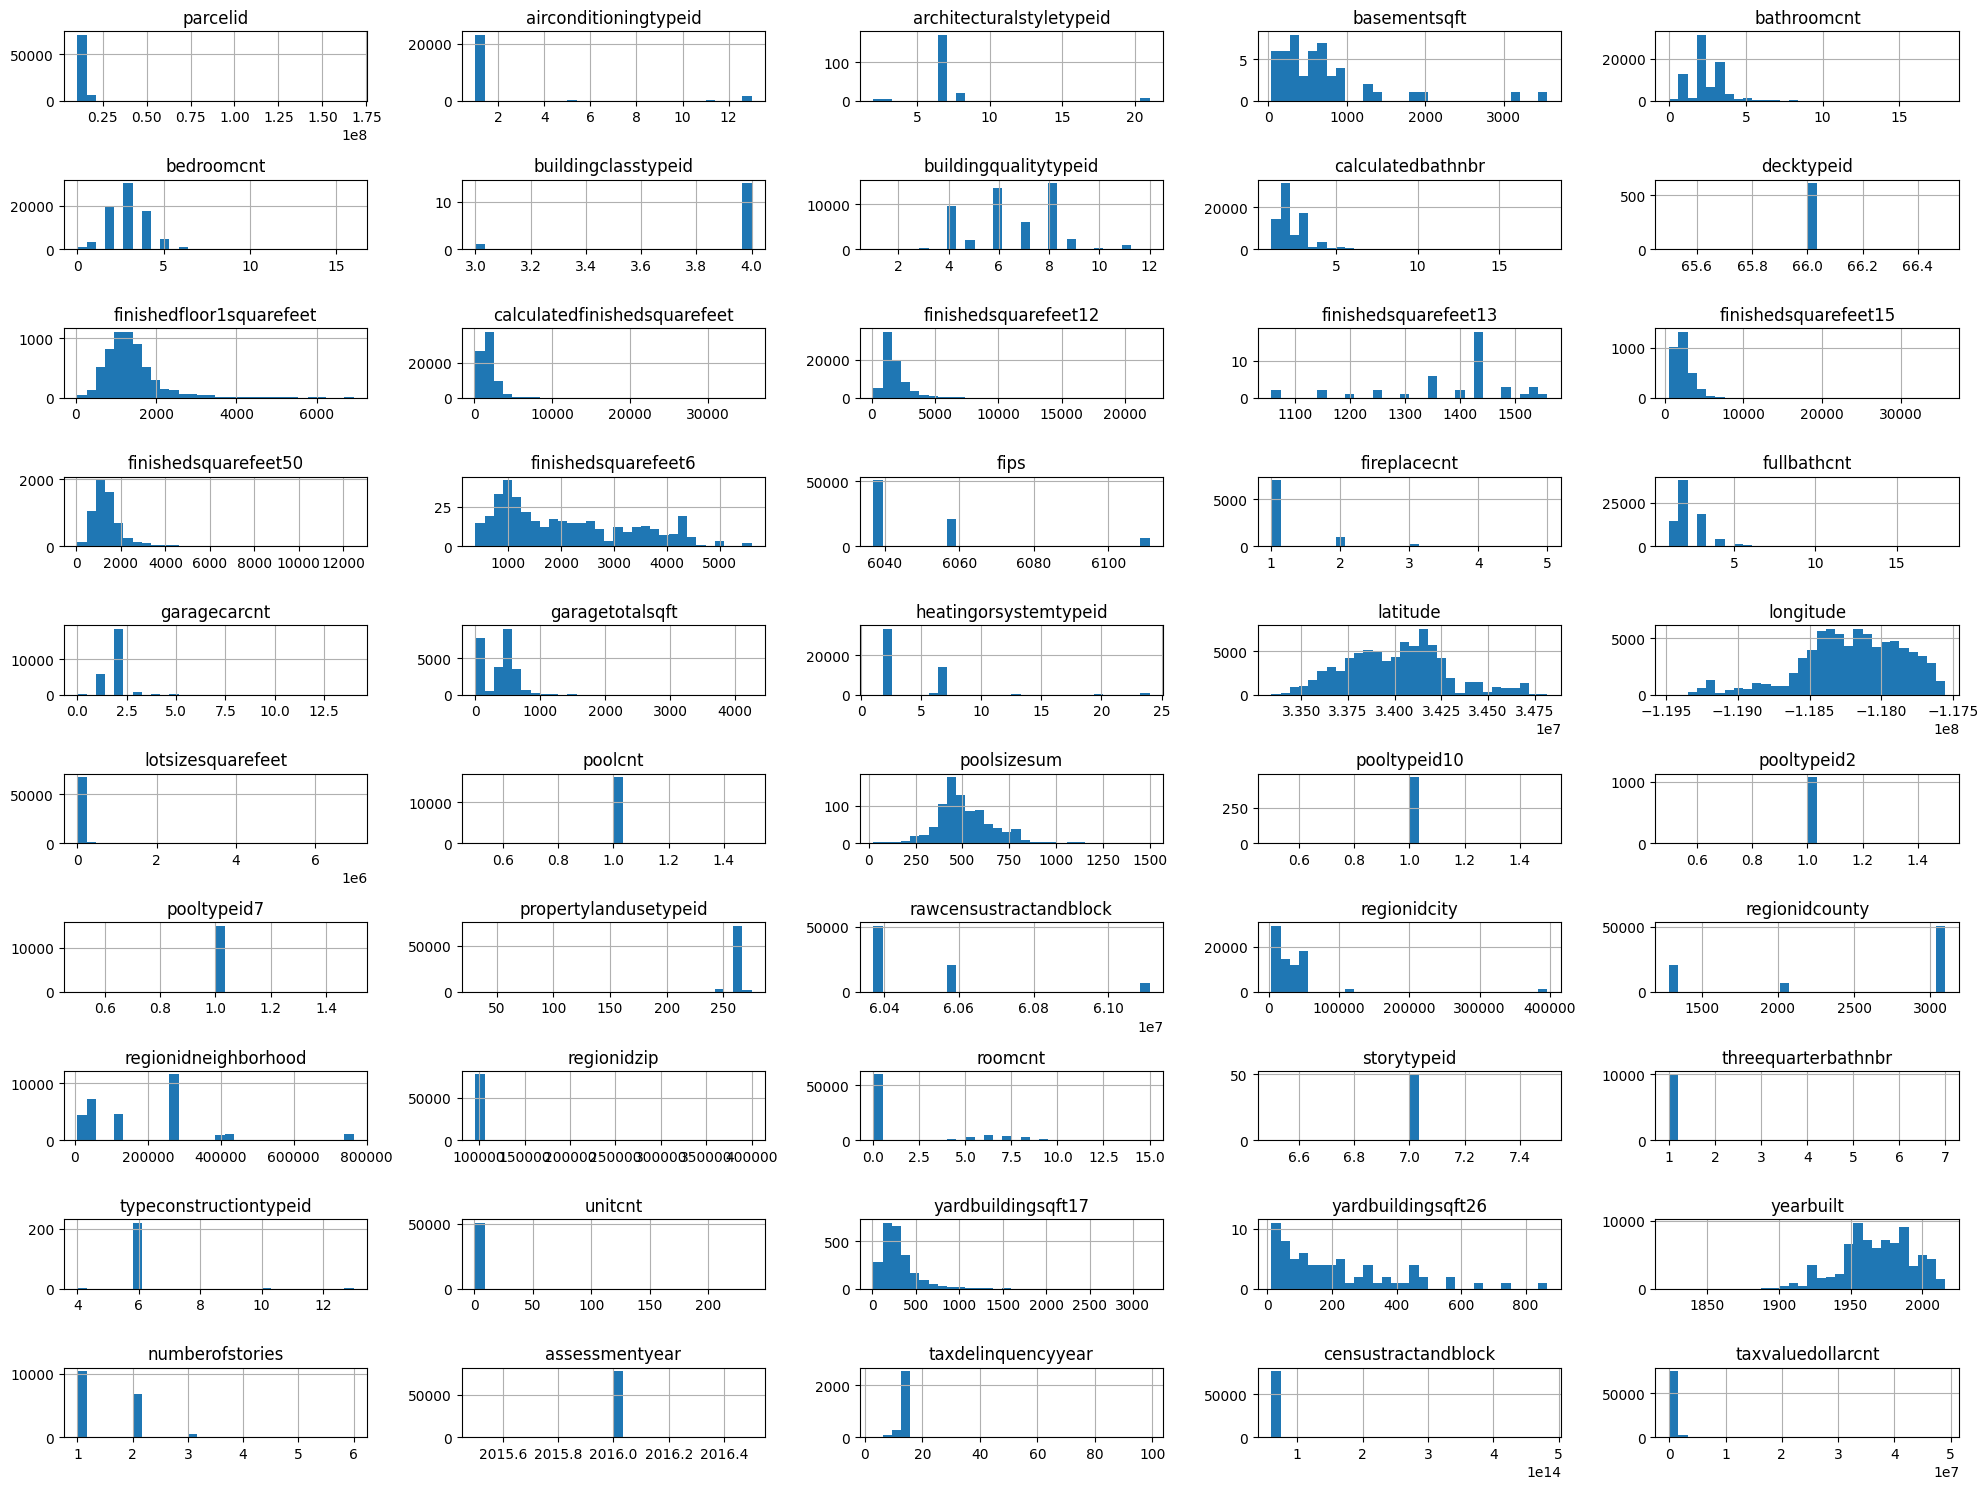

In [15]:
# Overview histograms for all numerical features
df.hist(figsize=(20, 15), bins=30, layout=(-1, 5))
plt.tight_layout()
plt.show()

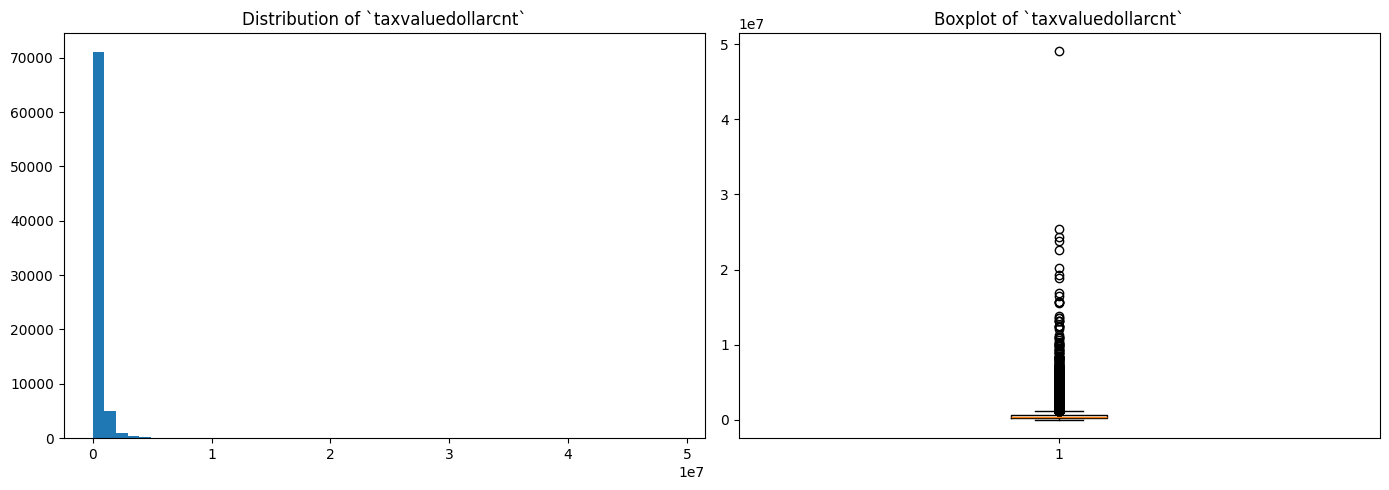

In [17]:
# Target variable: `taxvaluedollarcnt`

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['taxvaluedollarcnt'].dropna(), bins=50)
axes[0].set_title("Distribution of `taxvaluedollarcnt`")

# Boxplot
axes[1].boxplot(df['taxvaluedollarcnt'].dropna())
axes[1].set_title("Boxplot of `taxvaluedollarcnt`")

plt.tight_layout()
plt.show()

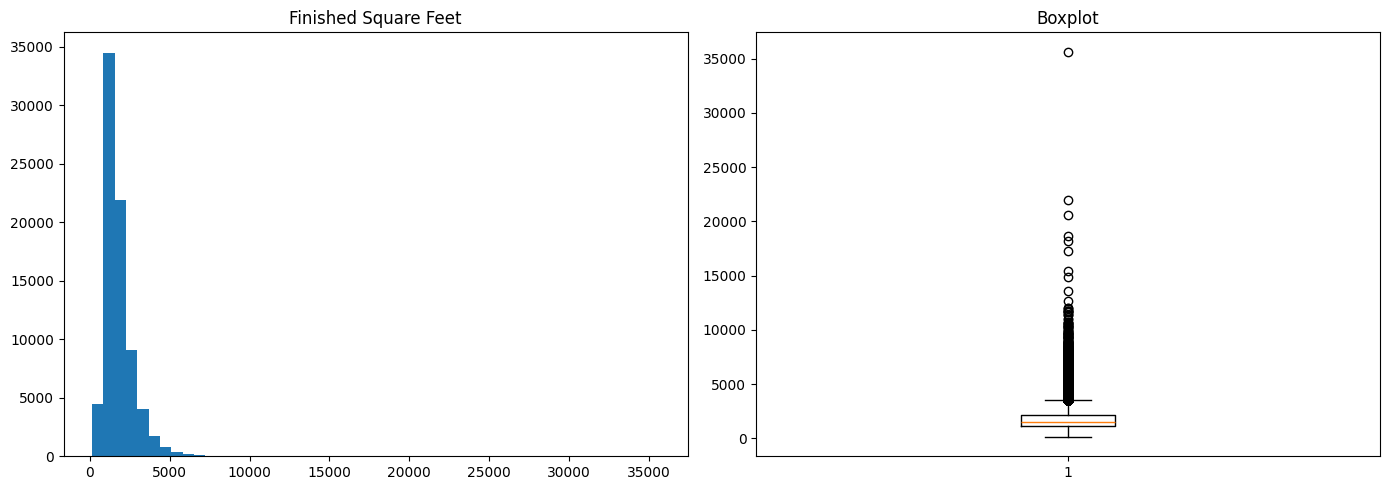

In [18]:
# Feature: `calculatedfinishedsquarefeet`

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['calculatedfinishedsquarefeet'].dropna(), bins=50)
axes[0].set_title("Finished Square Feet")

axes[1].boxplot(df['calculatedfinishedsquarefeet'].dropna())
axes[1].set_title("Boxplot")

plt.tight_layout()
plt.show()

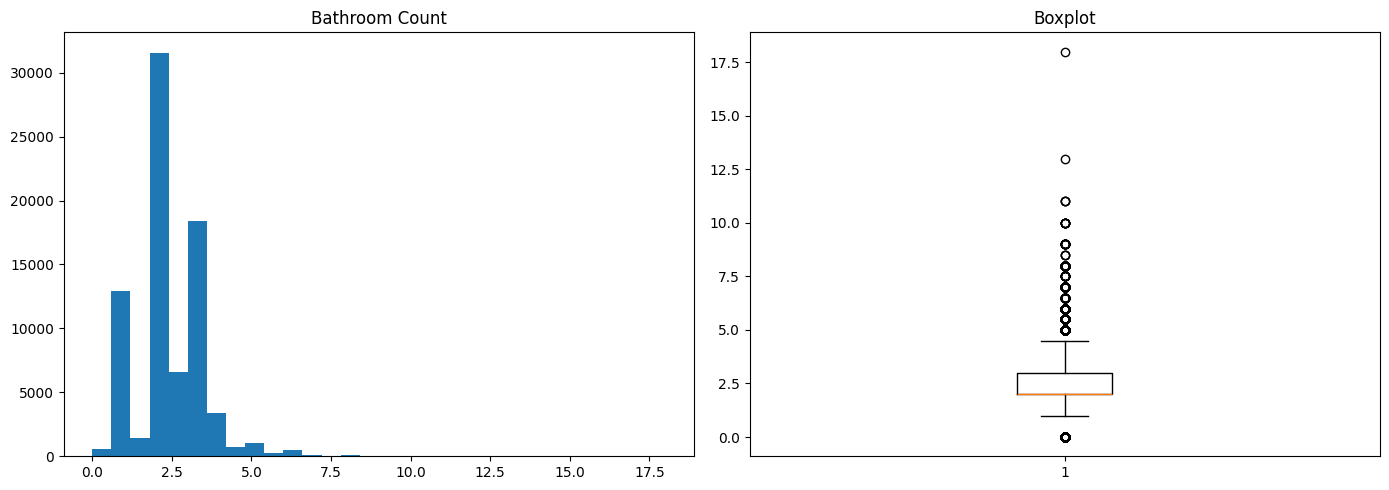

In [16]:
# Feature: `bathroomcnt`

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['bathroomcnt'].dropna(), bins=30)
axes[0].set_title("Bathroom Count")

axes[1].boxplot(df['bathroomcnt'].dropna())
axes[1].set_title("Boxplot")

plt.tight_layout()
plt.show()

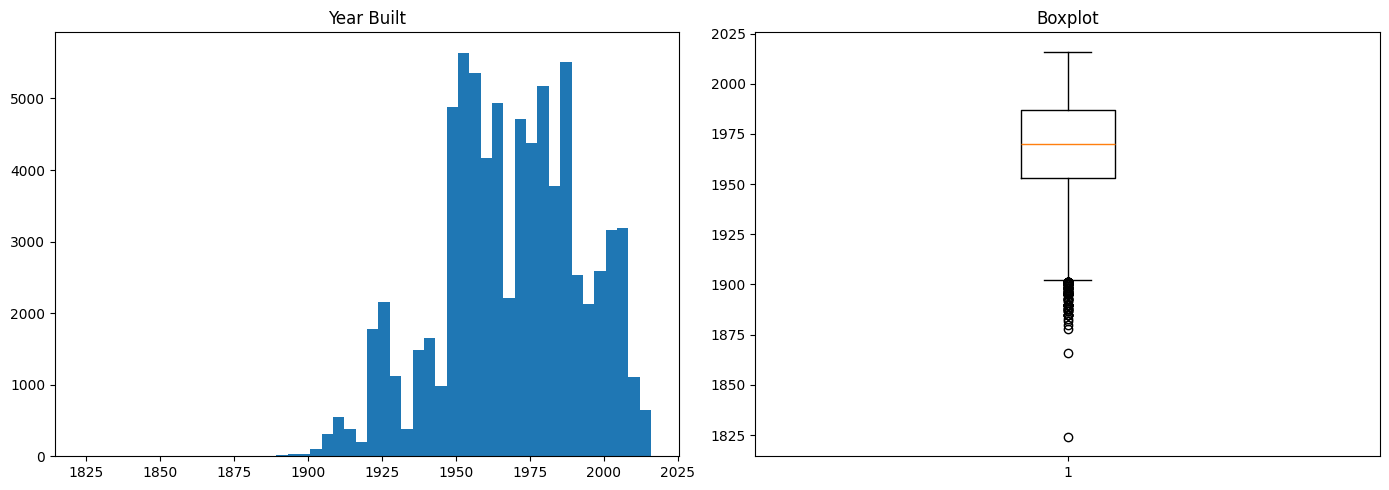

In [19]:
# Feature: `yearbuilt`

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['yearbuilt'].dropna(), bins=50)
axes[0].set_title("Year Built")

axes[1].boxplot(df['yearbuilt'].dropna())
axes[1].set_title("Boxplot")

plt.tight_layout()
plt.show()

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?


From the detailed examination of the selected features, several important patterns were observed. The target variable `taxvaluedollarcnt` is strongly right-skewed, with most properties concentrated at lower values and a small number of extremely high-value outliers. The boxplot clearly highlights these extreme values, suggesting that transformation or outlier handling may be necessary.

The feature `calculatedfinishedsquarefeet` shows a similar right-skewed distribution, where most homes fall within a moderate size range, but a few very large properties create noticeable outliers. This aligns with expectations, as larger homes tend to have higher property values and explains its strong relationship with the target.

The `bathroomcnt` feature has a more discrete distribution, with most properties having between 2 and 3 bathrooms. While less skewed, there are still some unusually high values, which may represent luxury homes or potential data anomalies.

In contrast, `yearbuilt` displays a more balanced distribution, with most homes built between the 1950s and early 2000s. Compared to other features, it is less skewed, though a few older properties appear as outliers.

Overall, the main patterns observed across these features are skewness and the presence of outliers, particularly in variables related to property size and value. These features were chosen because they are directly relevant to predicting property value and show meaningful variation, making them strong candidates for modeling. The observed skewness suggests that transformations (such as log scaling) may improve model performance in later steps.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [22]:
# Create clean copy
df_clean = df.copy()

# -------------------------------
# Drop identifier (no predictive value)
# -------------------------------
df_clean = df_clean.drop(columns=['parcelid'])

# -------------------------------
# Drop non-informative / ID-like features
# -------------------------------
cols_to_drop = [
    'rawcensustractandblock',   # long geographic ID (not meaningful for model)
    'censustractandblock',      # same as above
    'assessmentyear',           # almost constant (no variance)
    'propertycountylandusecode',# high-cardinality categorical code
    'propertyzoningdesc',       # text field with too many unique values
    'propertylandusetypeid'     # redundant land-use identifier
]

# Drop only if they exist (safe practice)
cols_to_drop = [col for col in cols_to_drop if col in df_clean.columns]
df_clean = df_clean.drop(columns=cols_to_drop)

# -------------------------------
# Drop constant / near-constant features (no variation)
# -------------------------------
constant_cols = ['decktypeid', 'hashottuborspa', 'poolcnt', 'storytypeid', 'fireplaceflag']
constant_cols = [col for col in constant_cols if col in df_clean.columns]
df_clean = df_clean.drop(columns=constant_cols)

# -------------------------------
# Check result
# -------------------------------
print("Final shape after Part 3.A:", df_clean.shape)

Final shape after Part 3.A: (77613, 43)


#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop. 


In this step, we removed features that are not useful for predicting the target variable based on their lack of predictive value.

The column `parcelid` was dropped because it is a unique identifier for each property and does not provide meaningful information for prediction. Including it could lead to overfitting, as the model might memorize individual records rather than learn general patterns.

We also removed identifier-like features such as `rawcensustractandblock` and `censustractandblock`, since they represent geographic codes rather than meaningful numerical relationships. Similarly, `assessmentyear` was dropped because it has little to no variation across the dataset and therefore does not contribute useful information.

Additionally, features such as `propertycountylandusecode` and `propertyzoningdesc` were removed due to their high number of unique values, making them difficult to encode effectively without adding unnecessary complexity. The feature `propertylandusetypeid` was also removed as it provides redundant information about property classification.

Finally, we removed features with little or no variation, including `decktypeid`, `poolcnt`, `hashottuborspa`, `storytypeid`, and `fireplaceflag`, since they do not help distinguish between observations.

Overall, the goal of this step was to simplify the dataset by removing non-informative features while keeping all potentially useful variables for further preprocessing and modeling.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [23]:
# Calculate the percentage of missing values for each feature
missing_pct = (df_clean.isnull().mean() * 100).round(2)

# Display features with the highest missing percentages
missing_pct.sort_values(ascending=False).head(20)

buildingclasstypeid         99.98
finishedsquarefeet13        99.95
basementsqft                99.94
yardbuildingsqft26          99.91
architecturalstyletypeid    99.73
typeconstructiontypeid      99.71
finishedsquarefeet6         99.50
pooltypeid10                99.40
poolsizesum                 98.88
pooltypeid2                 98.62
yardbuildingsqft17          96.92
taxdelinquencyflag          96.26
taxdelinquencyyear          96.26
finishedsquarefeet15        96.10
finishedfloor1squarefeet    92.22
finishedsquarefeet50        92.22
fireplacecnt                89.32
threequarterbathnbr         86.98
pooltypeid7                 80.57
numberofstories             77.32
dtype: float64

In [ ]:
# Set threshold
threshold = 70

# Identify features to drop
cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()

# Drop features
df_clean_v2 = df_clean.drop(columns=cols_to_drop)

# Print results
print(f"Dropped {len(cols_to_drop)} features with more than {threshold}% missing values:\n")
print(cols_to_drop)

print("\nDropped features:")
for col in cols_to_drop:
    print(f"- {col}")

Dropped 20 features with more than 70% missing values:

['architecturalstyletypeid', 'basementsqft', 'buildingclasstypeid', 'finishedfloor1squarefeet', 'finishedsquarefeet13', 'finishedsquarefeet15', 'finishedsquarefeet50', 'finishedsquarefeet6', 'fireplacecnt', 'poolsizesum', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7', 'threequarterbathnbr', 'typeconstructiontypeid', 'yardbuildingsqft17', 'yardbuildingsqft26', 'numberofstories', 'taxdelinquencyflag', 'taxdelinquencyyear']

Dropped features:
- architecturalstyletypeid
- basementsqft
- buildingclasstypeid
- finishedfloor1squarefeet
- finishedsquarefeet13
- finishedsquarefeet15
- finishedsquarefeet50
- finishedsquarefeet6
- fireplacecnt
- poolsizesum
- pooltypeid10
- pooltypeid2
- pooltypeid7
- threequarterbathnbr
- typeconstructiontypeid
- yardbuildingsqft17
- yardbuildingsqft26
- numberofstories
- taxdelinquencyflag
- taxdelinquencyyear


#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped



In this step, we removed features with a high percentage of missing values to improve the overall quality and reliability of the dataset.

Based on our analysis of missing values, we selected a threshold of 70%, meaning that any feature with more than 70% missing data was removed. This threshold was chosen as a balance between retaining useful information and eliminating features with insufficient data. Features with extremely high missing rates (often above 90%) contain very limited usable information and are poor candidates for imputation, as filling such large gaps could introduce bias and reduce model performance.

Several features, including `buildingclasstypeid`, `finishedsquarefeet13`, `basementsqft`, and `yardbuildingsqft26`, had extremely high levels of missing data. In addition, some pool-, fireplace-, and yard-related features also showed very low data availability, suggesting that they are either rare or inconsistently recorded.

Using this threshold, we dropped 20 features with more than 70% missing values. This reduced the dataset to 23 remaining features, resulting in a cleaner and more reliable dataset for further preprocessing and modeling.

Overall, this step helped reduce noise and dimensionality while preserving features with sufficient data coverage and stronger predictive potential.

### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [ ]:
# Create next version from previous step
df_clean_v3 = df_clean_v2.copy()

# Step 1: Drop rows where target is missing
before = df_clean_v3.shape[0]

df_clean_v3 = df_clean_v3.dropna(subset=['taxvaluedollarcnt'])

after = df_clean_v3.shape[0]
print(f"Dropped {before - after} rows with missing target values")

Dropped 35 rows with missing target values


In [ ]:
# Step 2: Remove extreme outliers in target (IQR method)
Q1 = df_clean_v3['taxvaluedollarcnt'].quantile(0.25)
Q3 = df_clean_v3['taxvaluedollarcnt'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

before = df_clean_v3.shape[0]

df_clean_v3 = df_clean_v3[
    (df_clean_v3['taxvaluedollarcnt'] >= lower_bound) &
    (df_clean_v3['taxvaluedollarcnt'] <= upper_bound)
]

after = df_clean_v3.shape[0]
print(f"Dropped {before - after} outlier rows based on target (IQR)")

Dropped 5186 outlier rows based on target (IQR)


In [ ]:
# Step 3: Drop rows with too many missing values
# (keep rows with at least 70% non-null values)
row_missing_pct = df_clean_v3.isnull().mean(axis=1)

before = df_clean_v3.shape[0]

df_clean_v3 = df_clean_v3[row_missing_pct < 0.3]

after = df_clean_v3.shape[0]
print(f"Dropped {before - after} rows with too many missing values")

# Final shape
print(f"Final dataset shape after cleaning samples: {df_clean_v3.shape}")

Dropped 1555 rows with too many missing values
Final dataset shape after cleaning samples: (70837, 23)


#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped


In this step, we removed problematic samples to improve the overall quality of the dataset. First, we dropped rows where the target variable 'taxvaluedollarcnt' was missing, since these observations cannot be used in a supervised learning model. 

Next, we removed extreme outliers in the target using the IQR method. The dataset contains unusually high property values that could distort the model, so removing these outliers helps improve model stability and prevents it from being overly influenced by rare cases. 

Finally, we removed rows with a high proportion of missing values (more than 30%), as these samples contain limited information and would require heavy imputation. In total, these steps reduced the dataset while preserving the majority of meaningful observations, resulting in a cleaner and more reliable dataset for modeling.

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [ ]:
from sklearn.impute import SimpleImputer

# Create next version
df_clean_v4 = df_clean_v3.copy()

# Separate numerical and categorical features
num_cols = df_clean_v4.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df_clean_v4.select_dtypes(include=['object']).columns.tolist()

# Remove target from numerical imputation list
num_cols = [col for col in num_cols if col != 'taxvaluedollarcnt']

print(f"Numerical features to impute: {len(num_cols)}")
print(f"Categorical features to impute: {len(cat_cols)}")

Numerical features to impute: 22
Categorical features to impute: 0


In [ ]:
# Median is used because many numerical features are skewed and contain outliers
num_imputer = SimpleImputer(strategy='median')
df_clean_v4[num_cols] = num_imputer.fit_transform(df_clean_v4[num_cols])

# Impute categorical features with most frequent value
if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df_clean_v4[cat_cols] = cat_imputer.fit_transform(df_clean_v4[cat_cols])

# Final check
print("Total remaining null values:", df_clean_v4.isnull().sum().sum())
print("Dataset shape after imputation:", df_clean_v4.shape)

assert df_clean_v4.isnull().sum().sum() == 0, "There are still missing values!"

Total remaining null values: 0
Dataset shape after imputation: (70837, 23)


#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset


For the remaining missing values, we applied different imputation methods based on the type of feature. Numerical features were imputed using the median, while categorical features were imputed using the most frequent value.

We chose median imputation for numerical variables because many of the key features, such as 'calculatedfinishedsquarefeet' and 'lotsizesquarefeet', showed skewed distributions and contained outliers. The median is more robust than the mean in these cases and helps preserve the overall structure of the data without being overly influenced by extreme values.

Categorical features were imputed using the most frequent value, which replaces missing entries with the most common category and maintains consistency within each feature.

These choices are consistent with the guidelines in Appendix 2 and allow us to handle missing data without introducing unnecessary complexity. After applying these methods, no missing values remained in the dataset, making it ready for further processing and modeling.

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

In [ ]:
# Create final dataset
df_clean_final = df_clean_v4.copy()

# Select categorical columns
cat_cols = df_clean_final.select_dtypes(include=['object']).columns.tolist()

print(f"Categorical features to encode: {len(cat_cols)}")
print(cat_cols)

Categorical features to encode: 0
[]


In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Apply encoding if categorical features exist
if len(cat_cols) > 0:
    encoder = OrdinalEncoder()
    df_clean_final[cat_cols] = encoder.fit_transform(df_clean_final[cat_cols])
    print(f"Encoded categorical features: {cat_cols}")
else:
    print("No categorical features to encode.")

# Verify all features are numeric
print("All features are numeric:", df_clean_final.select_dtypes(exclude=['number']).shape[1] == 0)

# Final dataset shape
print("Final dataset shape:", df_clean_final.shape)

# Preview final dataset
df_clean_final.head()

No categorical features to encode.
All features are numeric: True
Final dataset shape: (70837, 23)


,airconditioningtypeid,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fips,fullbathcnt,garagecarcnt,...,longitude,lotsizesquarefeet,regionidcity,regionidcounty,regionidneighborhood,regionidzip,roomcnt,unitcnt,yearbuilt,taxvaluedollarcnt
0,1.0,3.5,4.0,6.0,3.5,3100.0,3100.0,6059.0,3.0,2.0,...,-117869207.0,4506.0,53571.0,1286.0,118825.0,96978.0,0.0,1.0,1998.0,1023282.0
1,1.0,1.0,2.0,6.0,1.0,1465.0,1465.0,6111.0,1.0,1.0,...,-119281531.0,12647.0,13091.0,2061.0,118825.0,97099.0,5.0,1.0,1967.0,464000.0
2,1.0,2.0,3.0,6.0,2.0,1243.0,1243.0,6059.0,2.0,2.0,...,-117823170.0,8432.0,21412.0,1286.0,118825.0,97078.0,6.0,1.0,1962.0,564778.0
3,1.0,3.0,4.0,8.0,3.0,2376.0,2376.0,6037.0,3.0,2.0,...,-118240722.0,13038.0,396551.0,3101.0,118825.0,96330.0,0.0,1.0,1970.0,145143.0
4,1.0,3.0,3.0,8.0,3.0,1312.0,1312.0,6037.0,3.0,2.0,...,-118414640.0,278581.0,12447.0,3101.0,268548.0,96451.0,0.0,1.0,1964.0,119407.0


## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

In [ ]:
# Compute correlation matrix
corr_matrix = df_clean_final.corr()

# Correlation with target
target_corr = corr_matrix['taxvaluedollarcnt'].drop('taxvaluedollarcnt')

# Sort by absolute correlation for strongest relationships
target_corr_sorted = target_corr.sort_values(key=abs, ascending=False)

print("Top correlated features with target:")
print(target_corr_sorted.head(10))

print("\nLeast correlated features:")
print(target_corr.sort_values().head(10))

Top correlated features with target:
finishedsquarefeet12            0.482235
calculatedfinishedsquarefeet    0.476612
calculatedbathnbr               0.406101
bathroomcnt                     0.404954
fullbathcnt                     0.377806
bedroomcnt                      0.233697
yearbuilt                       0.223927
buildingqualitytypeid           0.203502
latitude                       -0.158673
regionidcounty                 -0.143895
Name: taxvaluedollarcnt, dtype: float64

Least correlated features:
latitude                -0.158673
regionidcounty          -0.143895
heatingorsystemtypeid   -0.142914
lotsizesquarefeet       -0.044723
regionidcity            -0.004940
longitude                0.002803
regionidzip              0.006256
unitcnt                  0.019701
airconditioningtypeid    0.046639
regionidneighborhood     0.047702
Name: taxvaluedollarcnt, dtype: float64


Features used in heatmap:
['finishedsquarefeet12', 'calculatedfinishedsquarefeet', 'calculatedbathnbr', 'bathroomcnt', 'fullbathcnt', 'bedroomcnt', 'yearbuilt', 'buildingqualitytypeid', 'latitude', 'regionidcounty', 'heatingorsystemtypeid', 'garagetotalsqft', 'garagecarcnt', 'fips', 'roomcnt', 'taxvaluedollarcnt']


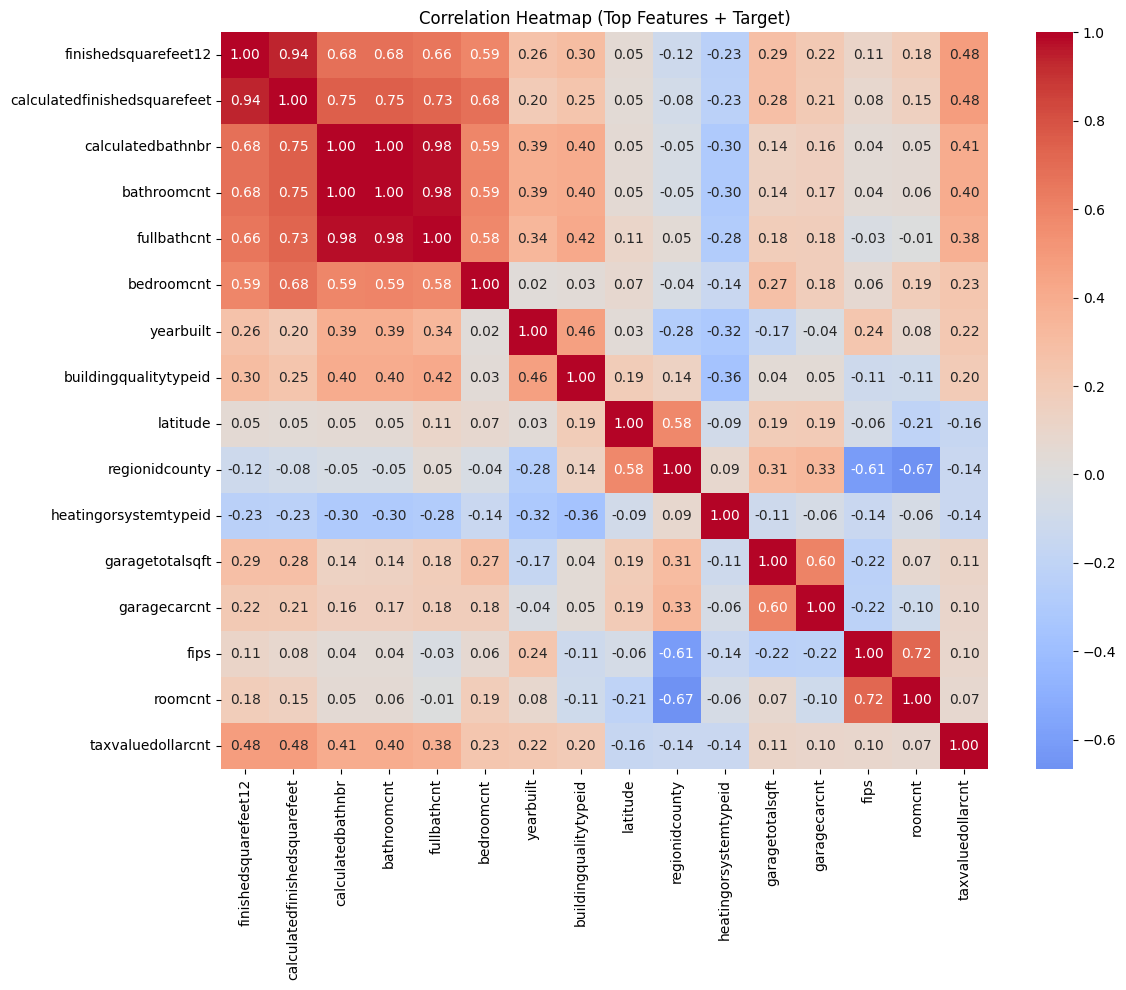

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select top 15 most strongly correlated features
top_features = target_corr_sorted.head(15).index.tolist()
top_features.append('taxvaluedollarcnt')

print("Features used in heatmap:")
print(top_features)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df_clean_final[top_features].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Top Features + Target)")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.feature_selection import f_regression
import pandas as pd

# Separate features and target
X_all = df_clean_final.drop(columns=['taxvaluedollarcnt'])
y_all = df_clean_final['taxvaluedollarcnt']

# Compute F-scores and p-values
f_scores, p_values = f_regression(X_all, y_all)

# Create DataFrame with results
f_score_df = pd.DataFrame({
    'Feature': X_all.columns,
    'F-score': f_scores,
    'p-value': p_values
}).sort_values(by='F-score', ascending=False)

print("F-statistics for all features:")
display(f_score_df)

F-statistics for all features:


,Feature,F-score,p-value
6,finishedsquarefeet12,21464.274442,0.000000e+00
5,calculatedfinishedsquarefeet,20820.329163,0.000000e+00
4,calculatedbathnbr,13988.972391,0.000000e+00
1,bathroomcnt,13894.595981,0.000000e+00
8,fullbathcnt,11794.322540,0.000000e+00
2,bedroomcnt,4092.091081,0.000000e+00
21,yearbuilt,3739.424451,0.000000e+00
3,buildingqualitytypeid,3060.233888,0.000000e+00
12,latitude,1829.481340,0.000000e+00
16,regionidcounty,1497.709510,4.940656e-324


<Figure size 1000x600 with 0 Axes>

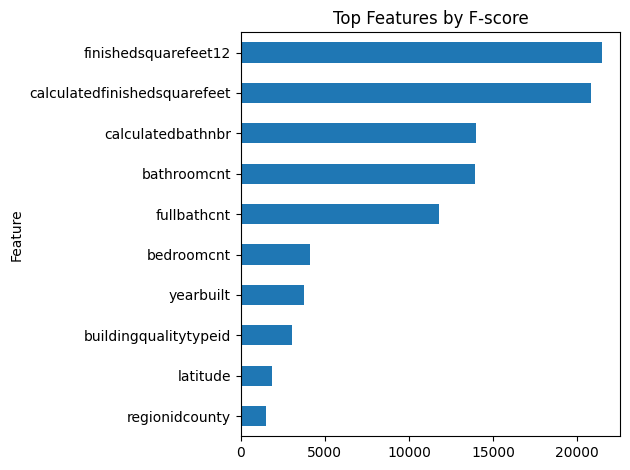

In [ ]:
# Plot top 10 features by F-score
plt.figure(figsize=(10, 6))
f_score_df.head(10).plot(kind='barh', x='Feature', y='F-score', legend=False)
plt.gca().invert_yaxis()
plt.title("Top Features by F-score")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector

# Use a smaller sample to reduce runtime
df_sample = df_clean_final.sample(n=2000, random_state=42)

X_sample = df_sample.drop(columns=['taxvaluedollarcnt'])
y_sample = df_sample['taxvaluedollarcnt']

# Use a simple linear model
simple_model = LinearRegression()

# Forward feature selection
forward_selector = SequentialFeatureSelector(
    simple_model,
    n_features_to_select=10,
    direction='forward',
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

forward_selector.fit(X_sample, y_sample)

forward_features = X_sample.columns[forward_selector.get_support()].tolist()

print("Forward Selected Features:")
print(forward_features)

Forward Selected Features:
['bathroomcnt', 'bedroomcnt', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'garagetotalsqft', 'latitude', 'longitude', 'regionidcounty', 'roomcnt', 'yearbuilt']


In [ ]:
# Backward feature selection
backward_selector = SequentialFeatureSelector(
    simple_model,
    n_features_to_select=10,
    direction='backward',
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

backward_selector.fit(X_sample, y_sample)

backward_features = X_sample.columns[backward_selector.get_support()].tolist()

print("Backward Selected Features:")
print(backward_features)

Backward Selected Features:
['bathroomcnt', 'bedroomcnt', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'garagetotalsqft', 'latitude', 'longitude', 'regionidcounty', 'roomcnt', 'yearbuilt']


In [ ]:
# Compare forward and backward feature selection results
common_features = set(forward_features) & set(backward_features)

print(f"Features selected by BOTH forward and backward: {common_features}")
print(f"Only in forward: {set(forward_features) - set(backward_features)}")
print(f"Only in backward: {set(backward_features) - set(forward_features)}")

Features selected by BOTH forward and backward: {'regionidcounty', 'roomcnt', 'garagetotalsqft', 'latitude', 'calculatedfinishedsquarefeet', 'yearbuilt', 'bathroomcnt', 'bedroomcnt', 'longitude', 'finishedsquarefeet12'}
Only in forward: set()
Only in backward: set()


#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships. 
 How do the different methods for seeing relationships compare? Do they agree or disagree?



From the analysis, the strongest relationships with `taxvaluedollarcnt` are driven by property size and structure. Features such as `finishedsquarefeet12` and `calculatedfinishedsquarefeet` show the highest correlations, followed by bathroom-related variables like `bathroomcnt` and `calculatedbathnbr`. This indicates that larger homes and those with more bathrooms tend to have higher tax values.

The F-statistic results support this pattern, ranking the same features as the most important predictors. This consistency suggests that these variables are both strongly related to the target and statistically significant.

Forward and backward feature selection methods produced nearly identical results, selecting key features such as square footage, room and bathroom counts, and location variables (`latitude`, `longitude`). The agreement between these methods increases confidence in the stability and importance of these features.

Overall, the results consistently show that property size, number of rooms/bathrooms, and location are the main drivers of property value, making them strong candidates for modeling.

### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

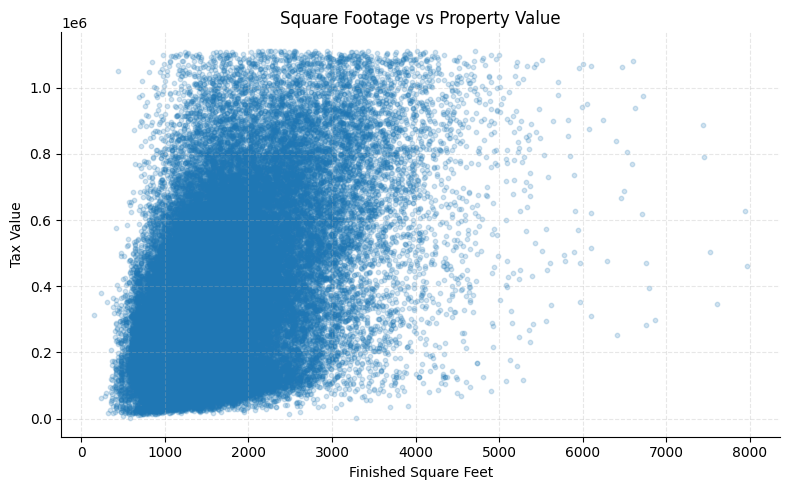

In [ ]:
# Feature Pair 1: Square footage vs Tax value
plt.figure(figsize=(8,5))
plt.scatter(df_clean_final['calculatedfinishedsquarefeet'],
            df_clean_final['taxvaluedollarcnt'],
            alpha=0.2, s=10)

plt.xlabel("Finished Square Feet")
plt.ylabel("Tax Value")
plt.title("Square Footage vs Property Value")

plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

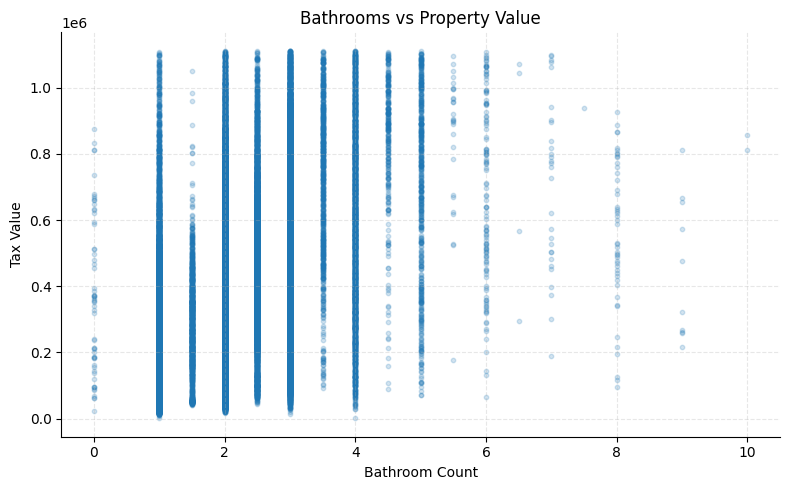

In [ ]:
# Feature Pair 2: Bathroom count vs Tax value
plt.figure(figsize=(8,5))
plt.scatter(df_clean_final['bathroomcnt'],
            df_clean_final['taxvaluedollarcnt'],
            alpha=0.2, s=10)

plt.xlabel("Bathroom Count")
plt.ylabel("Tax Value")
plt.title("Bathrooms vs Property Value")

plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

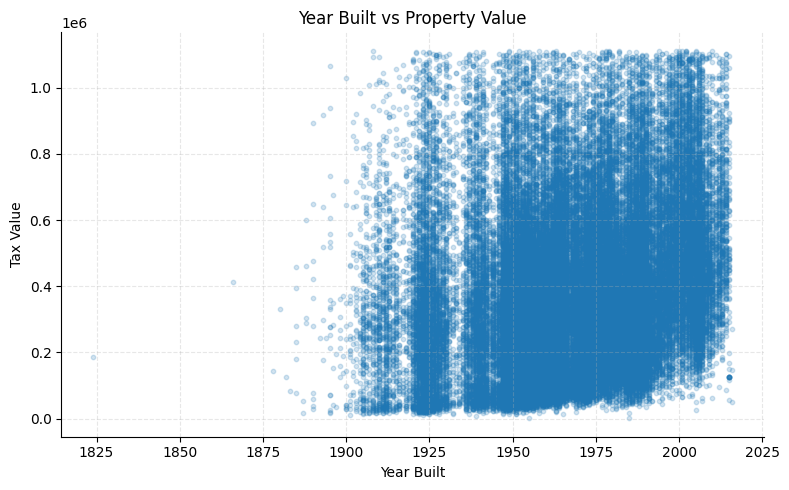

In [ ]:
# Feature Pair 3: Year built vs Tax value
plt.figure(figsize=(8,5))
plt.scatter(df_clean_final['yearbuilt'],
            df_clean_final['taxvaluedollarcnt'],
            alpha=0.2, s=10)

plt.xlabel("Year Built")
plt.ylabel("Tax Value")
plt.title("Year Built vs Property Value")

plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.


The scatter plots show clear and meaningful relationships between the selected features and the target variable, along with noticeable variability and outliers.

The relationship between `calculatedfinishedsquarefeet` and `taxvaluedollarcnt` shows a strong positive trend, indicating that larger homes tend to have higher property values. However, the spread increases for larger properties, suggesting higher variability and the presence of outliers, particularly for very large or high-value homes.

The relationship between `bathroomcnt` and property value is also positive but more discrete. Since bathroom count is an integer variable, the data forms vertical groupings. While properties with more bathrooms generally have higher values, the relationship is less consistent compared to square footage, and there is still variation within each group.

The relationship between `yearbuilt` and property value shows a weaker trend. Newer properties tend to have slightly higher values, but there is significant spread across all years, indicating that age alone is not a strong predictor compared to size and number of bathrooms.

Overall, these visualizations confirm that property size is the strongest driver of value, while features such as bathroom count and year built contribute to the model but with less consistent influence. The presence of variability and outliers also suggests that further transformations or modeling techniques may be needed to improve prediction performance.

## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_regression

# Copy final cleaned dataset
df_fe = df_clean_final.copy()

# Separate features and target
X = df_fe.drop(columns=['taxvaluedollarcnt'])
y = df_fe['taxvaluedollarcnt']

In [ ]:
# Transformation 1: Log transform of square footage
df_log = df_fe.copy()

df_log['log_sqft'] = np.log1p(df_log['calculatedfinishedsquarefeet'])

# Compare correlation before and after transformation
corr_original = df_log['calculatedfinishedsquarefeet'].corr(df_log['taxvaluedollarcnt'])
corr_log = df_log['log_sqft'].corr(df_log['taxvaluedollarcnt'])

print("Transformation 1: Log of Square Footage")
print(f"Original correlation with target: {corr_original:.4f}")
print(f"Log correlation with target:      {corr_log:.4f}")
print(f"Improvement: {abs(corr_log) - abs(corr_original):.4f}")

Transformation 1: Log of Square Footage
Original correlation with target: 0.4766
Log correlation with target:      0.4693
Improvement: -0.0073


In [ ]:
# Transformation 2: Convert year built into property age
df_age = df_fe.copy()

# Dataset is from 2017
df_age['property_age'] = 2017 - df_age['yearbuilt']

# Compare correlation before and after transformation
corr_year = df_age['yearbuilt'].corr(df_age['taxvaluedollarcnt'])
corr_age = df_age['property_age'].corr(df_age['taxvaluedollarcnt'])

print("Transformation 2: Property Age")
print(f"Year built correlation with target:    {corr_year:.4f}")
print(f"Property age correlation with target:  {corr_age:.4f}")

Transformation 2: Property Age
Year built correlation with target:    0.2239
Property age correlation with target:  -0.2239


In [ ]:
# Transformation 3: Square footage per room
df_ratio = df_fe.copy()

# Total rooms = bedrooms + bathrooms
df_ratio['total_rooms'] = df_ratio['bedroomcnt'] + df_ratio['bathroomcnt']

# Avoid division by zero
df_ratio['sqft_per_room'] = (
    df_ratio['calculatedfinishedsquarefeet'] /
    df_ratio['total_rooms'].replace(0, 1)
)

# Compare correlations
corr_rooms = df_ratio['total_rooms'].corr(df_ratio['taxvaluedollarcnt'])
corr_sqft_room = df_ratio['sqft_per_room'].corr(df_ratio['taxvaluedollarcnt'])

print("Transformation 3: Total Rooms and Sqft per Room")
print(f"Total rooms correlation with target:   {corr_rooms:.4f}")
print(f"Sqft per room correlation with target: {corr_sqft_room:.4f}")

Transformation 3: Total Rooms and Sqft per Room
Total rooms correlation with target:   0.3454
Sqft per room correlation with target: 0.2310


In [ ]:
# Transformation 4: Interaction between square footage and bathrooms
df_interact = df_fe.copy()

df_interact['sqft_bath_interaction'] = (
    df_interact['calculatedfinishedsquarefeet'] * df_interact['bathroomcnt']
)

corr_interaction = df_interact['sqft_bath_interaction'].corr(df_interact['taxvaluedollarcnt'])

print("Transformation 4: Square Footage × Bathroom Count")
print(f"Interaction feature correlation with target: {corr_interaction:.4f}")

Transformation 4: Square Footage × Bathroom Count
Interaction feature correlation with target: 0.4442


In [ ]:
# Transformation 5: Feature scaling
X_scaled = X.copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_scaled), columns=X.columns)

# Evaluate scaled features using F-score
f_scores_scaled, _ = f_regression(X_scaled, y)
scaled_scores = pd.Series(f_scores_scaled, index=X.columns)

print("Top features after scaling:")
print(scaled_scores.sort_values(ascending=False).head())

Top features after scaling:
finishedsquarefeet12            21464.274442
calculatedfinishedsquarefeet    20820.329163
calculatedbathnbr               13988.972391
bathroomcnt                     13894.595981
fullbathcnt                     11794.322540
dtype: float64


In [ ]:
# Evaluate engineered features using F-scores
engineered_features = pd.DataFrame({
    'log_sqft': df_log['log_sqft'],
    'property_age': df_age['property_age'],
    'total_rooms': df_ratio['total_rooms'],
    'sqft_per_room': df_ratio['sqft_per_room'],
    'sqft_bath_interaction': df_interact['sqft_bath_interaction']
})

f_new, p_new = f_regression(engineered_features, y)

f_new_df = pd.DataFrame({
    'Feature': engineered_features.columns,
    'F-Score': f_new,
    'p-value': p_new
}).sort_values(by='F-Score', ascending=False)

print("F-Statistics for engineered features:")
display(f_new_df)

F-Statistics for engineered features:


,Feature,F-Score,p-value
0,log_sqft,20006.994052,0.0
4,sqft_bath_interaction,17409.177366,0.0
2,total_rooms,9594.984175,0.0
3,sqft_per_room,3993.472485,0.0
1,property_age,3739.424451,0.0


#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed. 


In this section, we explored several feature engineering techniques to better capture patterns in the data based on insights from earlier analysis. Log transformation was applied to `calculatedfinishedsquarefeet` because it showed a right-skewed distribution. However, the results indicated that the transformation slightly reduced its correlation with the target, suggesting that the original relationship was already close to linear and did not benefit from the log scale. Similarly, log transformation of lot size showed very low predictive value and is unlikely to be useful.

We also created new features to better represent structural relationships within the data. The `property_age` feature (derived from `yearbuilt`) maintained similar predictive strength but reversed the direction of correlation, as expected. More importantly, combining features such as bedrooms and bathrooms into `total_rooms` improved correlation compared to using bedrooms alone, indicating that aggregated features can better capture property characteristics. The `sqft_per_room` ratio and the interaction feature between square footage and bathroom count also showed moderate to strong predictive value, suggesting that relationships between key variables can provide additional insight.

Finally, feature scaling was applied to standardize the data, which is important for many machine learning algorithms, although it does not directly affect correlation or F-scores. Overall, these transformations were chosen based on observed data patterns, and the results show that interaction and combined features are more beneficial than simple transformations such as logarithmic scaling. The usefulness of these features will be further evaluated during model development in the next milestone.

## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

